In [195]:
import numpy as np 
import scipy.special

In [196]:

class NeuralNetwork():

    #initialization fo the neural network
    def __init__(self, input_nodes, hidden_nodes, output_nodes, learning_rate):
        self.i_nodes = input_nodes
        self.h_nodes = hidden_nodes
        self.o_nodes = output_nodes

        self.lr = learning_rate
        #activation function is set to sigmoid activation function
        self.activation_function = lambda x: scipy.special.expit(x) 


        #link weights between input- and hidden-layer are initialized as a randomized matrix with the dimensions (i*h) where i is the number of input nodes and h is the number of hidden nodes
        self.wih_rand = np.random.rand(self.h_nodes, self.i_nodes)
        #alternatively for larger networks: Xavier initialization 
        self.wih_norm = np.random.normal(0.0, np.sqrt(1.0 / self.i_nodes), (self.h_nodes, self.i_nodes))
        
        #link weights between hidden- and output-layer are initialized as a randomized matrix with the dimensions (h*o) where h is the number of hidden nodes and o is the number of output nodes
        self.woh_rand = np.random.rand(self.h_nodes, self.o_nodes)
        #alternatively for larger networks: Xavier initialization 
        self.woh_norm = np.random.normal(0.0, np.sqrt(1.0 / self.h_nodes), (self.o_nodes, self.h_nodes))



    #query method to retrieve outputs from the network with respect to the current inputs (forward-propagation)
    def query(self, inputs_list):

        #input is converted into a 2d array
        inputs = np.array(inputs_list, ndmin=2).T

        #hidden-layer inputs and outputs are calculated
        hidden_inputs = np.dot(self.wih_norm, inputs)
        hidden_outputs = self.activation_function(hidden_inputs)

        #output-layer inputs and outputs are calculated 
        output_inputs = np.dot(self.woh_norm, hidden_outputs)
        output_outputs = self.activation_function(output_inputs)

        return output_outputs



    #training method for refining the link-weights with respect to the target values (backpropagation)
    def train(self, input_list, target_list):
        
        #input and target are converted into a 2d array
        inputs = np.array(input_list, ndmin=2).T
        targets = np.array(target_list, ndmin=2).T

        #forward propagation with the inputs 
        hidden_inputs = np.dot(self.wih_norm, inputs)
        hidden_outputs = self.activation_function(hidden_inputs)

        output_inputs = np.dot(self.woh_norm, hidden_outputs)
        output_outputs = self.activation_function(output_inputs)
        

        output_errors = targets-output_outputs
        
        #hidden errors are calculated by splitting output errors by weights
        hidden_errors = np.dot(self.woh_norm.T, output_errors)
        
        #weights are refined
        self.woh_norm += self.lr * np.dot((output_errors * output_outputs * (1.0 - output_outputs)), np.transpose(hidden_outputs))

        self.wih_norm += self.lr * np.dot((hidden_errors * hidden_outputs * (1.0 - hidden_outputs)), np.transpose(inputs))








Xavier initalization of weights:

weights are sampled from a normal propability distribution centered around 0.0 and with standart deviation that is related to the number of incoming links.
This takes into account the size of the previous layer to prevent vanishing gradients or exploding gradients

In [197]:
import matplotlib.pyplot as plt
%matplotlib inline

#data is read from the datafile and stored in a python list
data_file_train = open("mnist_train.csv", 'r')
data_list_train = data_file_train.readlines()
data_file_train.close()


#opens the training dataset
data_file_test = open("mnist_test.csv", 'r')
data_list_test = data_file_test.readlines()
data_file_test.close()



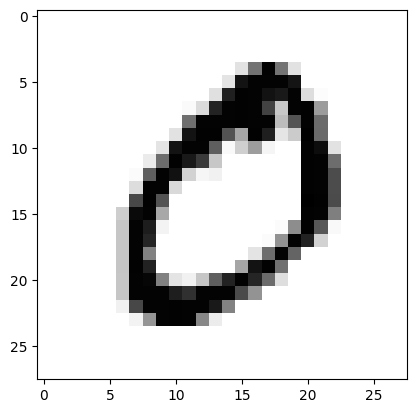

In [198]:
#display the image

val = data_list_train[1].split(',')
#values are reshaped into a (28,28) form except for the label of the data
image_array = np.asfarray(val[1:]).reshape((28,28))
plt.imshow(image_array, cmap='Greys', interpolation=None)


In [199]:
input_nodes = 784
hidden_nodes = 100
output_nodes = 10
learning_rate = 0.3

#instance of neural network with the parameters defined above is created
nn = NeuralNetwork(input_nodes, hidden_nodes, output_nodes, learning_rate)

In [200]:
for record in data_list_train:
    values = record.split(',')
    #inputs are rescaled to fit into the "comfort zone" of the neural network which is betweee 0.01 and 1.00
    scaled_inputs = (np.asfarray(values[1:])/ 255.0 * 0.99) + 0.1
    #target array is created with the floor value of 0.01 except for the correct label which should be 0.99
    targets = np.zeros(output_nodes) + 0.01
    targets[int(values[0])] = 0.99
    nn.train(scaled_inputs, targets)

In [203]:
scorecard = []

for record in data_list_test:
    values = record.split(',')

    correct_label = int(values[0])
    scaled_inputs = (np.asfarray(values[1:])/ 255.0 * 0.99) + 0.1
    outputs = nn.query(scaled_inputs)
    
    #max value of the networks outputs is the label the network guessed
    label = np.argmax(outputs)
    
    if label == correct_label:
        scorecard.append(1)
    else: 
        scorecard.append(0)

accuracy = sum(scorecard) / len(data_list_test)
print("Accuracy:", accuracy)

Accuracy: 0.9333
